## Exploratory Data Analysis (EDA)

In this section, we begin by examining the dataset to understand its overall structure and characteristics.  
First, we will check the number of rows and columns, the data types of each feature, and whether there are any missing values. This will help us ensure data quality and completeness.

Next, we will analyze the distribution of the features, especially focusing on the target variable — the match result (status) — to determine if the classes are balanced or imbalanced. Understanding class distribution is important for selecting appropriate evaluation metrics and modeling strategies.

Furthermore, we will explore numerical features such as the differences in the number of matches played, matches won, lost, tied, and goals scored or conceded by the home and away teams. By investigating these, we aim to uncover any potential relationships or patterns linked to match outcomes.

To aid this exploration, we will use visualizations such as histograms, box plots, and correlation matrices, which provide deeper insights into the data distribution and feature interactions.



In [319]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [320]:
df = pd.read_csv("matches.csv")
pd.set_option('display.max_columns', None)
df_qualifiers = df[df['wcm'] == 0].reset_index(drop=True)
df_wc = df[df['wcm'] == 1].reset_index(drop=True)


df_qualifiers.head(10)


,Unnamed: 0,home_team,home_goals,away_goals,away_team,wcm,dif_inter_match,dif_inter_match_won,dif_inter_match_lost,dif_inter_match_tie,dif_inter_goals_sco,dif_inter_goals_con,dif_wc_match,dif_wc_match_won,dif_wc_match_lost,dif_wc_match_tied,dif_wc_goals_sco,dif_wc_goals_con,status
0,0,Spain,1,0,Czechoslovakia,0,488.0,315.0,60.0,113.0,1061.0,346.0,33.0,19.0,4.0,10.0,55.0,27.0,1
1,1,Portugal,1,0,Czechoslovakia,0,438.0,222.0,113.0,103.0,748.0,466.0,0.0,3.0,-4.0,1.0,5.0,-10.0,1
2,2,Northern Ireland,7,0,Wales,0,-373.0,-164.0,-136.0,-73.0,-544.0,-409.0,8.0,2.0,4.0,2.0,9.0,19.0,1
3,3,Italy,4,2,Switzerland,0,-438.0,-120.0,-259.0,-59.0,-595.0,-936.0,46.0,33.0,0.0,13.0,78.0,13.0,1
4,4,Portugal,2,0,France,0,-191.0,-101.0,-61.0,-29.0,-388.0,-353.0,-36.0,-20.0,-9.0,-7.0,-71.0,-42.0,1
5,5,Germany,0,2,Italy,0,517.0,343.0,106.0,68.0,1402.0,629.0,26.0,22.0,5.0,-1.0,98.0,48.0,3
6,6,France,3,3,Switzerland,0,12.0,120.0,-106.0,-2.0,269.0,-264.0,29.0,22.0,2.0,5.0,70.0,13.0,2
7,7,England,5,2,Scotland,0,558.0,393.0,29.0,136.0,1538.0,362.0,46.0,25.0,7.0,14.0,66.0,23.0,1
8,8,Netherlands,1,1,Italy,0,411.0,230.0,125.0,56.0,1032.0,573.0,-33.0,-18.0,-6.0,-9.0,-42.0,-29.0,2
9,9,France,1,6,Belgium,0,53.0,68.0,-28.0,13.0,78.0,-104.0,18.0,14.0,0.0,4.0,52.0,5.0,3




### Class Distribution Analysis
Analyze the distribution of match outcomes to identify whether the classes are balanced or imbalanced


Class Distribution (status):
 status
1    0.483148
3    0.279624
2    0.237228
Name: proportion, dtype: float64


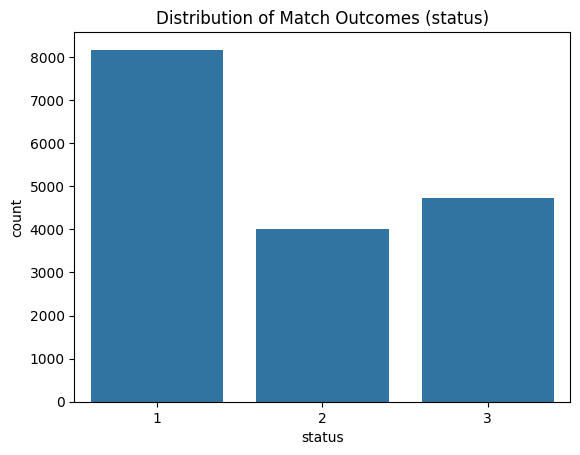

In [321]:
print("\nClass Distribution (status):\n", df_qualifiers['status'].value_counts(normalize=True))
sns.countplot(x='status', data=df_qualifiers)
plt.title('Distribution of Match Outcomes (status)')
plt.show()

The distribution of match outcomes (`status`) in the dataset is as follows:

- Home Win  : approximately 48.7%  
- Home Loss : approximately 27.7%  
- Draw      : approximately 23.6%  

This indicates that the dataset is somewhat imbalanced, with nearly half of the matches resulting in a home win, while home losses and draws occur less frequently. Such imbalance should be considered during model training and evaluation, as it may affect the model's ability to accurately predict minority classes. Techniques like class weighting or resampling could be used if needed to address this imbalance.


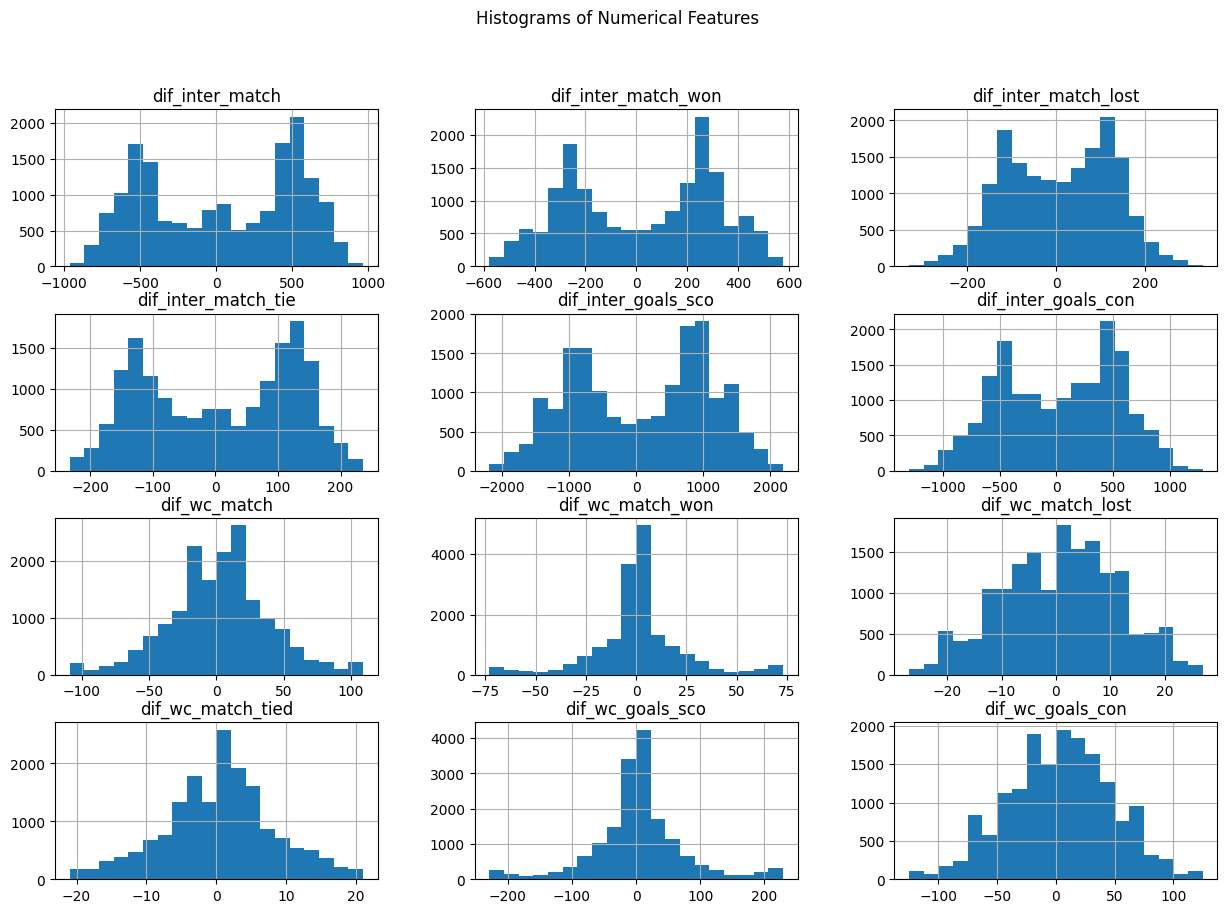

In [322]:
numeric_cols = [
    'dif_inter_match', 'dif_inter_match_won', 'dif_inter_match_lost', 'dif_inter_match_tie',
    'dif_inter_goals_sco', 'dif_inter_goals_con', 'dif_wc_match', 'dif_wc_match_won',
    'dif_wc_match_lost', 'dif_wc_match_tied', 'dif_wc_goals_sco', 'dif_wc_goals_con'
]

df_qualifiers[numeric_cols].hist(bins=20, figsize=(15,10))
plt.suptitle('Histograms of Numerical Features')
plt.show()


### Investigating Relationships Between Numerical Features and Match Outcomes

To explore potential relationships between the numerical features and the match results (`status`), we first encoded the categorical target variable into numeric codes. This encoding enables calculation of correlation coefficients.

We then computed and visualized the correlation matrix including all relevant numerical features along with the encoded match outcome. The resulting heatmap reveals the strength and direction of linear relationships between features and the target variable.

This approach helps identify which features have stronger linear associations with match results, guiding feature selection and providing insights into the data structure.

It is important to note that correlation measures only linear relationships and might miss more complex, nonlinear patterns. Additionally, since `status` is a categorical variable with multiple classes, correlation analysis should be complemented with other methods for a thorough understanding.

Overall, this correlation analysis serves as an effective initial step in understanding how numerical features relate to match outcomes.

### Correlation Insights from the Heatmap

Examining the heatmap, we observe some very strong positive correlations between certain numerical features:

- The correlation between `dif_inter_match_won` (difference in international matches won) and `dif_wc_goals_sco` (difference in World Cup goals scored) is extremely high at **0.99**. This suggests that teams with a higher number of international match wins tend to also have a significantly higher goal scoring record in World Cup matches.

- Similarly, `dif_inter_match_won` and `dif_wc_match_tied` (difference in World Cup matches tied) show a very strong positive correlation of **0.95**. This indicates that teams winning more international matches also tend to have more ties in World Cup matches, possibly reflecting consistent performance across different competitions.

These strong correlations highlight that historical international performance metrics are closely linked to World Cup match statistics, suggesting that past success can be predictive of future performance in the tournament.

However, such high correlations also imply redundancy between features, which should be considered during feature selection or dimensionality reduction to avoid multicollinearity issues in modeling.


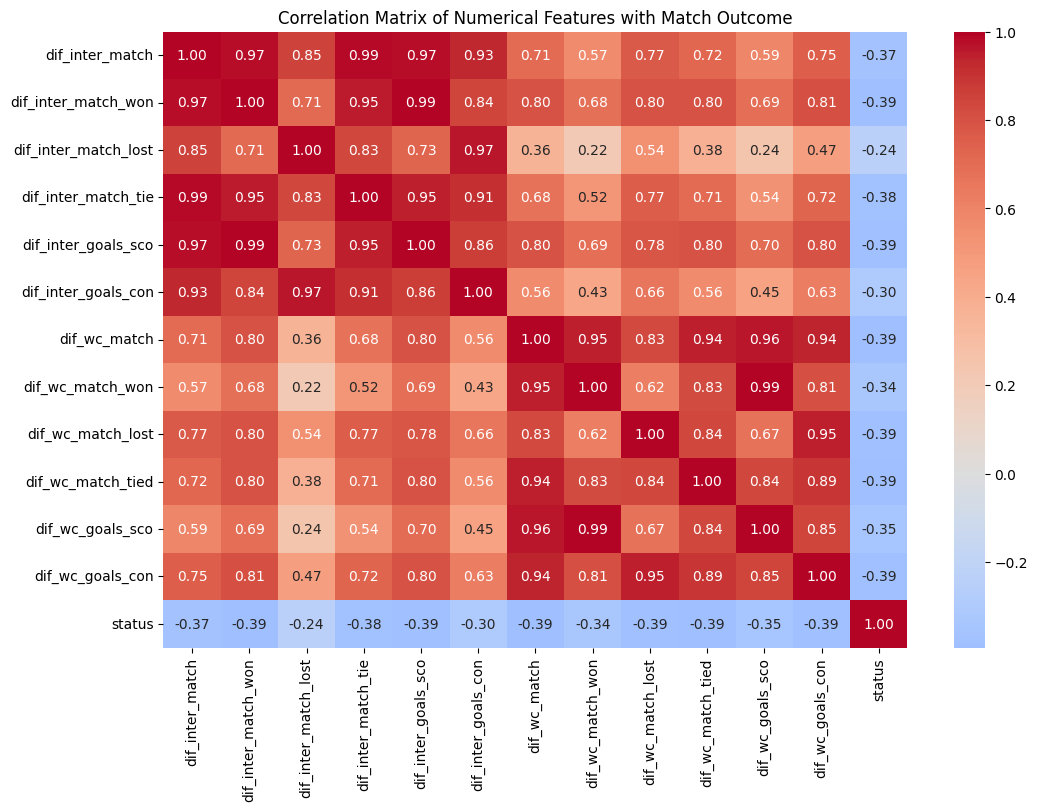

In [323]:
corr = df_qualifiers[numeric_cols + ['status']].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features with Match Outcome')
plt.show()

### Analysis of Team Performance in Home and Away Matches

We analyzed the relationship between the average number of goals scored by teams and their winning rates in both home and away matches.

Our scatter plots indicate a generally linear relationship: teams that score more goals tend to have higher winning percentages. This finding aligns with the intuitive understanding that scoring more goals increases the likelihood of winning.

However, we also observed several outliers in both home and away match data. These outliers represent unusual match results or exceptional performances that deviate significantly from the general trend. While outliers can sometimes distort model training, their presence is expected in sports data due to the unpredictable nature of matches.

Overall, this analysis validates logical patterns in the dataset and confirms that goal-scoring performance is a key factor influencing match outcomes. The existence of outliers highlights the variability inherent in football matches and suggests the need for careful handling during model development.


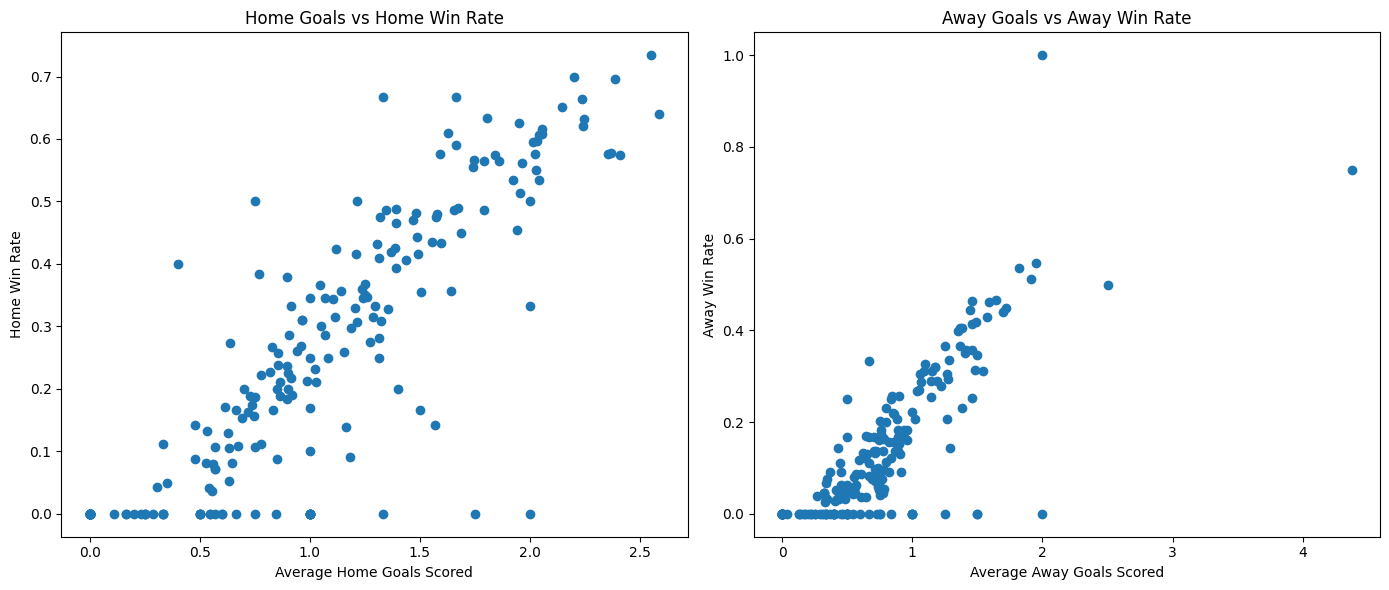

In [324]:
home_stats = df_qualifiers.groupby('home_team').agg({
    'home_goals': ['mean', 'sum'],
    'away_goals': ['mean', 'sum'],
    'status': lambda x: (x == 1).mean()
}).reset_index()
home_stats.columns = ['team', 'avg_home_goals_scored', 'total_home_goals_scored', 'avg_home_goals_conceded', 'total_home_goals_conceded', 'home_win_rate']

away_stats = df_qualifiers.groupby('away_team').agg({
    'away_goals': ['mean', 'sum'],
    'home_goals': ['mean', 'sum'],
    'status': lambda x: (x == 3).mean()
}).reset_index()
away_stats.columns = ['team', 'avg_away_goals_scored', 'total_away_goals_scored', 'avg_away_goals_conceded', 'total_away_goals_conceded', 'away_win_rate']

combined_stats = pd.merge(home_stats, away_stats, on='team', how='outer').fillna(0)

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.scatter(combined_stats['avg_home_goals_scored'], combined_stats['home_win_rate'])
plt.xlabel('Average Home Goals Scored')
plt.ylabel('Home Win Rate')
plt.title('Home Goals vs Home Win Rate')

plt.subplot(1,2,2)
plt.scatter(combined_stats['avg_away_goals_scored'], combined_stats['away_win_rate'])
plt.xlabel('Average Away Goals Scored')
plt.ylabel('Away Win Rate')
plt.title('Away Goals vs Away Win Rate')

plt.tight_layout()
plt.show()


In [325]:
features_to_drop = ['home_team', 'away_team', 'home_goals', 'away_goals', 'status']

X = df_qualifiers.drop(columns = features_to_drop)
y = df_qualifiers['status']
X.head(10)


,Unnamed: 0,wcm,dif_inter_match,dif_inter_match_won,dif_inter_match_lost,dif_inter_match_tie,dif_inter_goals_sco,dif_inter_goals_con,dif_wc_match,dif_wc_match_won,dif_wc_match_lost,dif_wc_match_tied,dif_wc_goals_sco,dif_wc_goals_con
0,0,0,488.0,315.0,60.0,113.0,1061.0,346.0,33.0,19.0,4.0,10.0,55.0,27.0
1,1,0,438.0,222.0,113.0,103.0,748.0,466.0,0.0,3.0,-4.0,1.0,5.0,-10.0
2,2,0,-373.0,-164.0,-136.0,-73.0,-544.0,-409.0,8.0,2.0,4.0,2.0,9.0,19.0
3,3,0,-438.0,-120.0,-259.0,-59.0,-595.0,-936.0,46.0,33.0,0.0,13.0,78.0,13.0
4,4,0,-191.0,-101.0,-61.0,-29.0,-388.0,-353.0,-36.0,-20.0,-9.0,-7.0,-71.0,-42.0
5,5,0,517.0,343.0,106.0,68.0,1402.0,629.0,26.0,22.0,5.0,-1.0,98.0,48.0
6,6,0,12.0,120.0,-106.0,-2.0,269.0,-264.0,29.0,22.0,2.0,5.0,70.0,13.0
7,7,0,558.0,393.0,29.0,136.0,1538.0,362.0,46.0,25.0,7.0,14.0,66.0,23.0
8,8,0,411.0,230.0,125.0,56.0,1032.0,573.0,-33.0,-18.0,-6.0,-9.0,-42.0,-29.0
9,9,0,53.0,68.0,-28.0,13.0,78.0,-104.0,18.0,14.0,0.0,4.0,52.0,5.0


In [326]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_encoded[:20]


array([0, 0, 0, 0, 0, 2, 1, 0, 1, 2, 1, 1, 2, 1, 2, 2, 1, 0, 2, 1])

In [327]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

### Feature Standardization Using StandardScaler

`StandardScaler` standardizes the features by removing the mean and scaling to unit variance, transforming each feature to have a mean of zero and a standard deviation of one. 

Standardization is important because it ensures all features contribute equally to the model training and prevents features with larger scales from dominating. Applying the scaler fitted only on training data avoids data leakage, which could lead to overly optimistic evaluation results.


In [328]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [329]:
import torch
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

### Model Definition:

We defined a Multi-Layer Perceptron (MLP) model using PyTorch by creating a class that inherits from `torch.nn.Module`. The model class implements two essential methods:

- `__init__`: Initializes the network layers based on the specified input size, a list of hidden layer sizes, and the output size (number of classes). The hidden layers use fully connected (`Linear`) layers followed by ReLU activation functions.

- `forward`: Defines the forward pass of the model, taking input tensor `X` and passing it sequentially through the network layers to produce the output logits.

This flexible design allows arbitrary depth and width for the MLP, enabling experimentation with different architectures to best fit the data.


In [330]:
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(MLP, self).__init__()
        layers = []
        in_size = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(in_size, h))
            layers.append(nn.ReLU())
            in_size = h
        layers.append(nn.Linear(in_size, output_size))
        self.network = nn.Sequential(*layers)
        
    def forward(self, X):
        return self.network(X)

input_dim = X_train_tensor.shape[1]
hidden_layers = [64, 32]
output_dim = len(le.classes_)

model = MLP(input_dim, hidden_layers, output_dim)



In [331]:
from torch.utils.data import DataLoader, TensorDataset

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

batch_size = 64
epochs = 20

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")


Epoch 1/20 - Loss: 0.9685
Epoch 2/20 - Loss: 0.9484
Epoch 3/20 - Loss: 0.9455
Epoch 4/20 - Loss: 0.9429
Epoch 5/20 - Loss: 0.9414
Epoch 6/20 - Loss: 0.9404
Epoch 7/20 - Loss: 0.9386
Epoch 8/20 - Loss: 0.9375
Epoch 9/20 - Loss: 0.9366
Epoch 10/20 - Loss: 0.9351
Epoch 11/20 - Loss: 0.9347
Epoch 12/20 - Loss: 0.9336
Epoch 13/20 - Loss: 0.9323
Epoch 14/20 - Loss: 0.9313
Epoch 15/20 - Loss: 0.9306
Epoch 16/20 - Loss: 0.9294
Epoch 17/20 - Loss: 0.9291
Epoch 18/20 - Loss: 0.9285
Epoch 19/20 - Loss: 0.9279
Epoch 20/20 - Loss: 0.9277


In [332]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs, 1)
    total = y_test_tensor.size(0)
    correct = (predicted == y_test_tensor).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 56.62%


In [333]:
df_wc.head(100)

,Unnamed: 0,home_team,home_goals,away_goals,away_team,wcm,dif_inter_match,dif_inter_match_won,dif_inter_match_lost,dif_inter_match_tie,dif_inter_goals_sco,dif_inter_goals_con,dif_wc_match,dif_wc_match_won,dif_wc_match_lost,dif_wc_match_tied,dif_wc_goals_sco,dif_wc_goals_con,status
0,16912,France,4,1,Mexico,1,-58.0,-48.0,15.0,-25.0,-87.0,175.0,9.0,18.0,-8.0,-1.0,60.0,-21.0,1
1,16913,United States,3,0,Belgium,1,-62.0,-23.0,-24.0,-15.0,-325.0,-277.0,-15.0,-12.0,0.0,-3.0,-31.0,-10.0,1
2,16914,Yugoslavia,2,1,Brazil,1,-746.0,-511.0,-85.0,-150.0,-1697.0,-545.0,-72.0,-57.0,-5.0,-10.0,-169.0,-59.0,1
3,16915,Romania,3,1,Peru,1,-94.0,-15.0,-72.0,-7.0,-75.0,-170.0,3.0,3.0,-2.0,2.0,9.0,-1.0,1
4,16916,Argentina,1,0,France,1,123.0,101.0,-40.0,62.0,298.0,-102.0,15.0,9.0,4.0,2.0,17.0,16.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,17007,Germany,2,0,Yugoslavia,1,712.0,438.0,126.0,148.0,1676.0,748.0,72.0,51.0,9.0,12.0,166.0,79.0,1
96,17008,Hungary,4,2,Brazil,1,-615.0,-461.0,-27.0,-127.0,-1462.0,-293.0,-77.0,-58.0,-4.0,-15.0,-142.0,-48.0,1
97,17009,Germany,6,1,Austria,1,624.0,421.0,67.0,136.0,1580.0,559.0,80.0,55.0,9.0,16.0,183.0,78.0,1
98,17010,Hungary,4,2,Uruguay,1,-568.0,-258.0,-159.0,-151.0,-815.0,-552.0,-24.0,-9.0,-6.0,-9.0,0.0,-17.0,1


In [334]:
features_to_drop = ['home_team', 'away_team', 'home_goals', 'away_goals', 'status']

X_wc = df_wc.drop(columns=features_to_drop)
y_wc = df_wc['status']


X_wc_scaled = scaler.transform(X_wc)
X_wc_tensor = torch.tensor(X_wc_scaled, dtype=torch.float32)
y_wc_encoded = le.transform(y_wc)
y_wc_tensor = torch.tensor(y_wc_encoded, dtype=torch.long)


model.eval()
with torch.no_grad():
    outputs = model(X_wc_tensor)
    _, predicted = torch.max(outputs, 1)
    total = y_wc_tensor.size(0)
    correct = (predicted == y_wc_tensor).sum().item()

accuracy_wc = 100 * correct / total
print(f"World Cup Test Accuracy: {accuracy_wc:.2f}%")



World Cup Test Accuracy: 54.22%


## Run FIFA World CUP!
In this part, we are going to use our model to predict the tournament including group
stage and knockout stage

In [335]:
import itertools
import random
import torch
import pandas as pd
import warnings
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings("ignore")
groups = {
    'Group A': ['Qatar', 'Ecuador', 'Senegal', 'Netherlands'],
    'Group B': ['England', 'Iran', 'USA', 'Wales'],
    'Group C': ['Argentina', 'Saudi Arabia', 'Mexico', 'Poland'],
    'Group D': ['France', 'Australia', 'Denmark', 'Tunisia'],
    'Group E': ['Spain', 'Costa Rica', 'Germany', 'Japan'],
    'Group F': ['Belgium', 'Canada', 'Morocco', 'Croatia'],
    'Group G': ['Brazil', 'Serbia', 'Switzerland', 'Cameroon'],
    'Group H': ['Portugal', 'Ghana', 'Uruguay', 'South Korea']
}

features_to_drop = ['home_team', 'away_team', 'home_goals', 'away_goals', 'status']

def predict_game(row):
    features = row.drop(features_to_drop).values.reshape(1, -1)
    features_scaled = scaler.transform(features) 
    features_tensor = torch.tensor(features_scaled, dtype=torch.float32)
    
    model.eval()
    with torch.no_grad():
        output = model(features_tensor)
        probabilities = torch.softmax(output, dim=1)
        pred_class = torch.argmax(probabilities).item() + 1  
    return pred_class

output = ""
results = {}

# Group Stage
for group, teams in groups.items():
    points = {team: 0 for team in teams}
    output += f"\n{group} Matches:\n"
    
    group_matches = df_wc[
        (df_wc['home_team'].isin(teams)) & (df_wc['away_team'].isin(teams))
    ].reset_index(drop=True)

    existing_pairs = set()
    for idx, row in group_matches.iterrows():
        pair = tuple(sorted([row['home_team'], row['away_team']]))
        existing_pairs.add(pair)

    all_possible_pairs = list(itertools.combinations(teams, 2))
    missing_pairs = [pair for pair in all_possible_pairs if pair not in existing_pairs]

    for idx, row in group_matches.iterrows():
        result = predict_game(row)
        home_team = row['home_team']
        away_team = row['away_team']
        
        if result == 1:
            points[home_team] += 3
            outcome = f"{home_team} wins"
        elif result == 2:
            points[home_team] += 1
            points[away_team] += 1
            outcome = "Draw"
        else:
            points[away_team] += 3
            outcome = f"{away_team} wins"
        
        output += f"{home_team} vs {away_team}: {outcome}\n"

    # Random Prediction
    for t1, t2 in missing_pairs:
        result = random.choice([1, 3])
        if result == 1:
            points[t1] += 3
            outcome = f"{t1} wins (random)"
        else:
            points[t2] += 3
            outcome = f"{t2} wins (random)"
        output += f"{t1} vs {t2}: {outcome}\n"

    ranked = sorted(points.items(), key=lambda x: x[1], reverse=True)
    output += f"Standings for {group}:\n"
    for rank, (team, pts) in enumerate(ranked, 1):
        output += f"{rank}. {team} - {pts} points\n"
    
    #the first two teams of each group are qualified for the knockout stage
    results[group] = ranked[:2] 

output += "\nQualified Teams for Knockout Stage:\n"
for group, qualified_teams in results.items():
    output += f"{group}: {[team for team, pts in qualified_teams]}\n"

# Round of 16
output += "\nKnockout Stage Matches (Round of 16):\n"
round_of_16_winners = []

for g1, g2 in [('Group A', 'Group B'), ('Group C', 'Group D'), ('Group E', 'Group F'), ('Group G', 'Group H')]:
    t1 = results[g1][0][0]
    t2 = results[g2][1][0]
    winner1 = simulate_match(t1, t2)
    output += f"{t1} (1st {g1}) vs {t2} (2nd {g2}): {winner1} wins\n"
    round_of_16_winners.append(winner1)

    t3 = results[g1][1][0]
    t4 = results[g2][0][0]
    winner2 = simulate_match(t3, t4)
    output += f"{t3} (2nd {g1}) vs {t4} (1st {g2}): {winner2} wins\n"
    round_of_16_winners.append(winner2)

# Quarter Final
output += "\nQuarter Final Matches:\n"
quarter_final_winners = []
for i in range(0, len(round_of_16_winners), 2):
    t1, t2 = round_of_16_winners[i], round_of_16_winners[i + 1]
    winner = simulate_match(t1, t2)
    output += f"{t1} vs {t2}: {winner} wins\n"
    quarter_final_winners.append(winner)

# Semi Final
output += "\nSemi Final Matches:\n"
semi_final_winners = []
for i in range(0, len(quarter_final_winners), 2):
    t1, t2 = quarter_final_winners[i], quarter_final_winners[i + 1]
    winner = simulate_match(t1, t2)
    output += f"{t1} vs {t2}: {winner} wins\n"
    semi_final_winners.append(winner)

# Final
output += "\nFinal Match:\n"
final_winner = simulate_match(semi_final_winners[0], semi_final_winners[1])
output += f"{semi_final_winners[0]} vs {semi_final_winners[1]}: {final_winner} wins\n"

with open("worldcup_full_tournament_results.txt", "w", encoding="utf-8") as f:
    f.write(output)

print("Full tournament results saved to 'worldcup_full_tournament_results.txt'")


Full tournament results saved to 'worldcup_full_tournament_results.txt'
